# Public Opinion and Film: How do Movies Reflect Current Events and Societal Moods? 
Tessa Reilly

## Introduction            


The film industry is one of the most powerful tools for social commentary. As filmmakers and studios pull inspiration from real-world events, these ideas are reflected on screen. Not only do films provide insight into current societal issues and events, but they also have the power to influence society. They can be simply a critique of the most popular social issues, but have a profound impact (Ahmed, 2024).

As societal moods, opinions, and events are reflected in the film industry, public opinion and current events provide context for movies and the film industry. For example, horror films about disease may have become more popular in 2021 and 2022 following the COVID-19 pandemic, reflecting a major social issue at the time. Furthermore, The Hunger Games raised awareness about political issues like propaganda and authoritarianism (Ahmed, 2024), which is now becoming increasingly relevant in today's tumultuous political climate. Whether films be a reflection of an important event or opinion, critique, or influence society, they all have their roots in the real world.

Our project seeks to explore how the film industry reflects current events by analyzing the complete IMDb Database. We study popular movie genres and ratings over time and contextualize them with outside research on societal events in order to examine the trends seen in the IMDb Database and the relationship between film and social events.

Ethical Considerations: Overall, the IMDb database seems to be relatively ethical. While it primarily relies on user-submitted data, which could diminish its reliability, the IMDb does not release usernames of users, making it more ethical. However, since the data is submitted by real IMDb users, it could cause some manipulation of the ratings of films, which could potentially impact our findings.


## Database Design 


The IMDb dataset provides an overview of worldwide movies, TV shows, and short films, capturing a wide range of variables such as genres, ratings, reviews, and other indicators of film popularity. This dataset has been widely used to identify patterns in audience response, cultural shifts, and industry trends over time. As major historical events and global themes have unfolded, cinema has often reflected and responded to these changes. We believe the IMDb dataset effectively captures these times, making it a valuable resource for analyzing the relationship between real-world events and cinematic expression.

## Data Exploration        


In [159]:
import sqlite3
conn = sqlite3.connect('imdb_full_spring_25.db')
c = conn.cursor()

import pandas as pd

import matplotlib.pyplot as plt 

import seaborn as sns

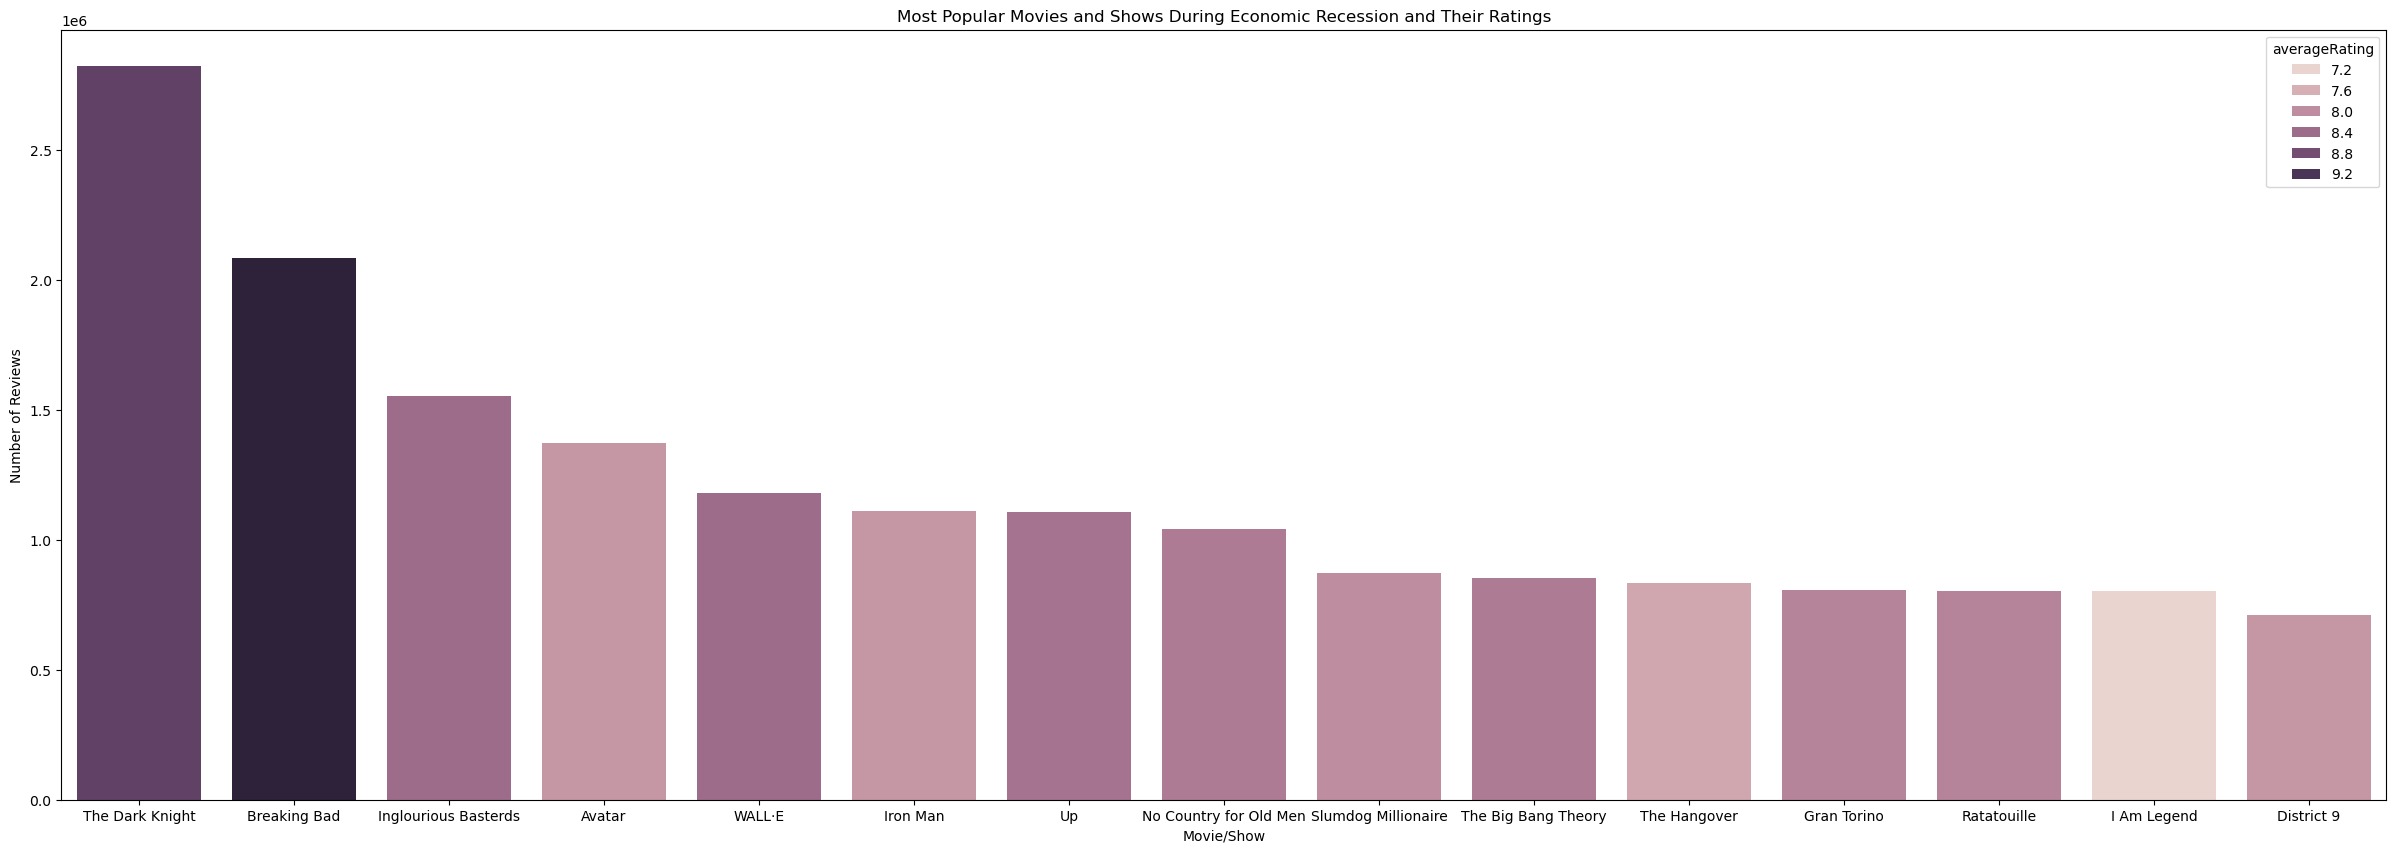

In [161]:
sql = ('''SELECT title_basics._id, title_basics.titleId AS titleId, title_basics.primaryTitle AS primaryTitle, title_basics.startYear AS startYear, 
          ratings.averageRating AS averageRating, ratings.numVotes AS numVotes FROM title_basics INNER JOIN ratings ON title_basics._id=ratings.titleId
          WHERE title_basics.startYear > 2006 AND title_basics.startYear < 2010 ORDER BY ratings.numVotes DESC LIMIT 15''')

query1 = pd.read_sql(sql,conn)

#bar graph of this for visualization 1
plt.figure(figsize = (30,10))
plt.title('Most Popular Movies and Shows During Economic Recession and Their Ratings')
plt.xlabel('Movie/Show')
plt.ylabel('Number of Reviews')
sns.barplot( x = 'primaryTitle', y = 'numVotes', hue = 'averageRating', data = query1)
plt.show()

Almost all of the media here are action/adventure, many of which take place in worlds that are different from our own. Many of these media were also very dark in terms of theme and tone. After doing some outside research most movies where the subject was the actual recession didn't come out until after the recession had ended. Based on these results it seems like audiences wanted an escape from their reality during this time. To confirm this claim more research and queries in the IMDB database would have to be done to see what medias were most popular during other eras to see how they compare and contrast to the media that was most popular during the recession.

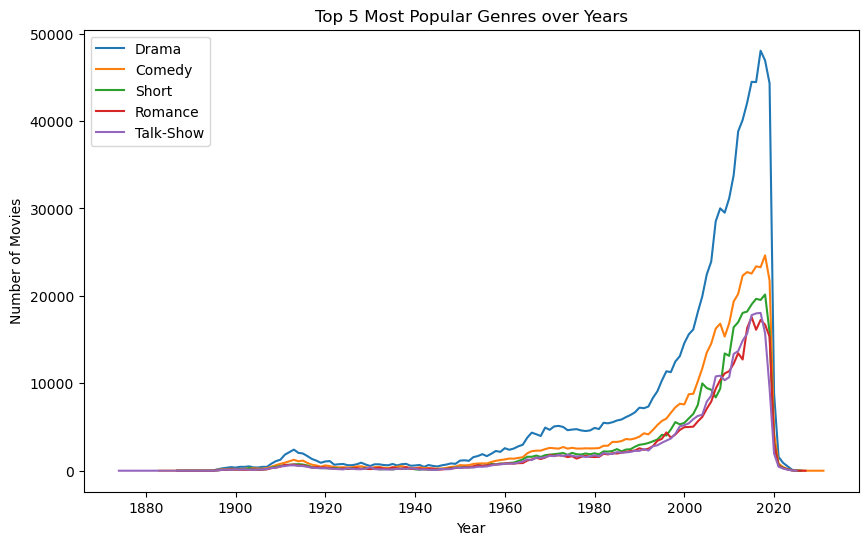

In [164]:
sql = """
SELECT genres.genre, title_basics.startYear FROM genres INNER JOIN title_basics ON genres._id = title_basics._id 
WHERE genres.genre != '\\N' AND title_basics.startYear != '\\N' 
"""

df = pd.read_sql(sql, conn)

df = df[df['genre'].notnull()]
df['startYear'] = df['startYear'].astype(int)

genre_counts = df.groupby(['startYear', 'genre']).size().reset_index(name='count')


top_genres = genre_counts.groupby('genre')['count'].sum().nlargest(5).index.tolist()
genre_counts = genre_counts[genre_counts['genre'].isin(top_genres)]


plt.figure(figsize=(10, 6))
for genre in top_genres:
    sub = genre_counts[genre_counts['genre'] == genre].sort_values('startYear')
    plt.plot(sub['startYear'], sub['count'], label=genre)

plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.title('Top 5 Most Popular Genres over Years')
plt.legend()
plt.show() 

This graph shows how the number of movies made in the top five genres, including Drama, Comedy, Short, Romance, and Talk-Show has changed over time, from the late 1800s up to around 2025. Drama leads with the most movies, especially from the 1980s onward, with a huge spike that peaks just before 2020. Comedy and the other genres follow a similar upward trend, though not quite as extreme. What really stands out, though, is the sharp drop across all genres right after 2019. This sudden drop off lines up with the COVID-19 pandemic, which impacted the film industry, causing major delays, shutdowns, and a big slowdown in production overall. 

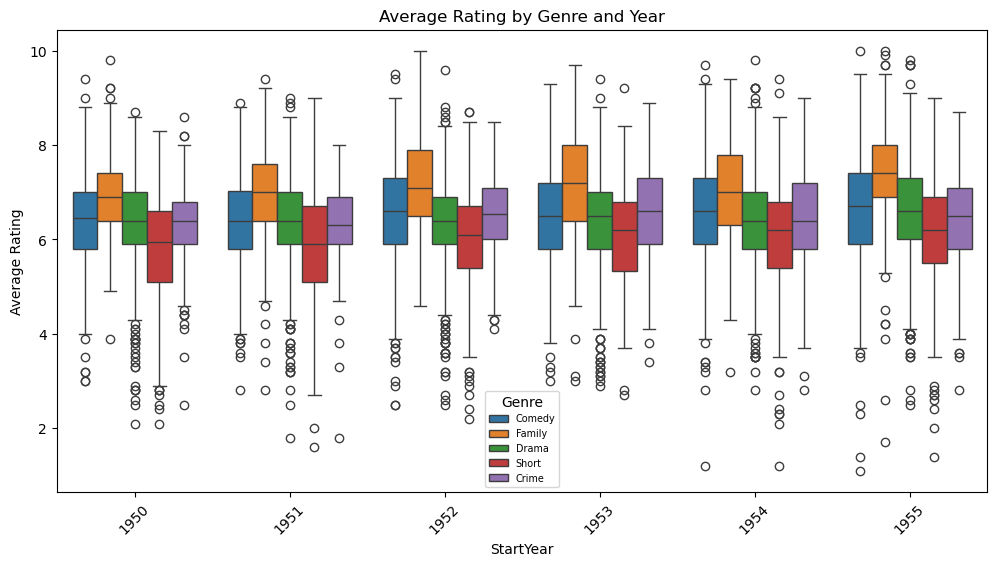

In [177]:
sql = ('''SELECT 
    title_basics._id, 
    title_basics.titleId AS TitleId, 
    title_basics.startYear AS startYear, 
    ratings.averageRating AS averageRating, 
    genres.genre
FROM title_basics
INNER JOIN ratings ON title_basics._id = ratings.titleId
INNER JOIN genres ON title_basics._id = genres.titleId
WHERE title_basics.startYear >= 1950 AND title_basics.startYear <= 1955''')

query3 = pd.read_sql(sql, conn)

genre_counts2 = query3.groupby(['startYear', 'genre']).size().reset_index(name='count')

top_genres2 = genre_counts2.groupby('genre')['count'].sum().nlargest(5).index.tolist()

query3 = query3[query3['genre'].isin(top_genres2)]

#vis for query 3
plt.figure(figsize=(12, 6))
sns.boxplot(x='startYear', y='averageRating', hue='genre', data=query3)
plt.xlabel('StartYear')
plt.ylabel('Average Rating')
plt.title('Average Rating by Genre and Year')
plt.xticks(rotation=45)
plt.legend(title='Genre', fontsize='x-small')
plt.show()

This boxplot shows the average ratings for the five most commonly produced genres between 1950 and 1955. These genres are Comedy, Family, Drama, Short, and Crime. During this time period, family films clearly had the highest average rating. The Family genre also had the fewest outliers, further supporting the idea that these films were the most well-liked. The early 1950s were a difficult time in the United States, marked by the end of World War II, the Korean War, and the Cold War. The public likely wanted an escape from reality during this time, which is why feel-good family movies were the most popular. 

## Uses of Python: Technical Components

    
| Component | Usage | Explanation | 
|:---|:---|:---|
| _leave this column as-is_ | _name the method(s)/ function(s) you used_ | _Use this area to explain what you were trying to achieve with this particular use of code and to describe why you chose to use this particular method or approach_ | 
| complex SQL query 1 | pd.read_sql| Retrieves data from both ratings and title_basics in order to find the top 15 most popular movies and TV shows during the financial recession to see how the current events impacted what people watched.|
| complex SQL query 2| pd.read_sql, SELECT, etc. | This query selects data from the title_basics and genres tables and performs an inner join on them, and removes any null values. It also creates a variable for the count of movies in a specific year and genre, and creates a new variable to store the 5 genres with the highest counts.| 
| complex SQL query 3 | pd.read_sql, SELECT, etc.| This retrieves columns from the title_basics, ratings, and genres tables and joins them for films produced between 1944 and 1954 to reflect how World War II impacted films.| 
| table join | INNER JOIN | A table join was done in the SQL query to get data from both ratings and title_basics.| 
| GROUP BY clause | df.groupby(['startYear', 'genre'])| This was used to group and organize the genre_counts variable in the second query/visualization.| 
| WHERE clause | WHERE startYear > 2006 AND < 2010 | This was used to get movies/shows only from the years 2007 to 2009, which was during the US economic recession.| 
| one of LIKE, HAVING, LIMIT, ORDER BY | ORDER BY | This was used to get the most popular movies in terms of the number of votes they received.| 
| one SQLite function (e.g., count, max, min, etc.) | count | This was used in the second data query/visualization to count the number of movies in each genre over time. | 
| dataviz 1 | sns.barplot | This is a barplot that shows the 15 most popular movies in terms of the number of reviews during the economic recession and gives them a color assignment based on the average review score to try to see how the recession impacted what kind of media people wanted to consume. | 
| dataviz 2 | plt.figure | This is a line plot that shows the 5 most popularly produced genres over time. Each line is a different color representing a different genre, and represents the number of movies produced in that genre at that time.| 
| dataviz 3 | sns.scatterplot |This is a scatterplot that shows the average ratings of films released between 1944 and 1954 and assigns a color to each point based on the genre to explore how films impacted and reflected public opinions during and following World War II.| 

## Uses of Python: Reflection          


For Query 1, the table join was performed directly in the SQL query because the ratings table’s reference key and title_basic’s primary key have different names. This simplified the process and was the most efficient way of combination. The results were stored in a Pandas dataframe for easy manipulation and visualization. The bar chart produced compared the most popular movies during the economic recession based on reviews and average ratings.

In Query 2, the goal was to analyze the most popular movie genres over time. Our SQL query filtered out null values and grouped the data by start year and genre to count movies per genre each year. It was important that we excluded n/a values for the most efficient visualization. After loading the data into a dataframe, we visualized the trends of the top 5 genres using a line plot. The line plot provides the best view of genre popularity over time.

For Query 3, the analysis focused on movies from the 1950s. The SQL query retrieved data for movies released between 1950 and 1955, grouping by the start year and genre to calculate genre counts. We used a box plot to visualize the distribution of average ratings for each genre, showing differences in ratings across genres. 

Overall, we believe we were efficient in our use of queries and code. Each time frame or topic we selected to depict was carefully chosen based on a current event in the world that happened during the time frame. The visualizations accurately depict what the film industry looked like during The Great Recession, the Covid Pandemic, and the years following WWII. 

## References

SQLite Tutorial. (n.d.). SQLite Tutorial – Learn SQLite fast and easy. https://www.sqlitetutorial.net

SQLite Tutorial. (n.d.). SQLite GROUP BY. https://www.sqlitetutorial.net/sqlite-group-by/

Wharton UME. (2021, March 20). COVID’s impact on the film industry: The biggest shift in the history of Hollywood. https://www.whartonume.com/blog/covids-impact-on-the-film-industry-the-biggest-shift-in-the-history-of-hollywood 

Gaughan, L. (2025, April 3). The 15 best movies about the 2008 financial crisis. Collider. https://collider.com/best-movies-2008-financial-crisis/

Ahmed, A. (n.d.). The impact of film on society: A deeper look. Medium. https://medium.com/@ayazahmed96320/the-impact-of-film-on-society-a-deeper-look-6f8d4b18c16f#:~:text=Films%20often%20reflect%20the%20society,reinforcing%20or%20challenging%20existing%20beliefs

Manzoor, S. (2023). How do films reflect our societies today? An analysis of films and film genre. ResearchGate. 
https://www.researchgate.net/publication/376031073_How_do_Films_Reflect_our_Societies_Today_An_Analysis_of_Films_and_Film_Genre 